In [3]:
from sklearn.metrics import mean_squared_error
y_true=[3,-0.5,2,7]
y_pred=[2.5,0.1,2,8]
mse=mean_squared_error(y_true,y_pred)
print("\n Mean squared error :",mse)  


 Mean squared error : 0.40249999999999997


In [4]:
from sklearn.metrics import mean_absolute_error
y_true=[3,-0.5,2,7]
y_pred=[2.5,0.1,2,8]
mse=mean_absolute_error(y_true,y_pred)
print("\n Mean squared error :",mse)  


 Mean squared error : 0.525


In [5]:
#logistic regression 
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

data = load_iris()
X = data.data
y = data.target


X = X[y != 2]
y = y[y != 2]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Predicted Values:", y_pred)
print("Actual Values   :", y_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Predicted Values: [1 1 1 0 0 0 0 1 0 0 0 0 1 0 1 0 1 1 0 0]
Actual Values   : [1 1 1 0 0 0 0 1 0 0 0 0 1 0 1 0 1 1 0 0]
Accuracy: 1.0


In [6]:
from sklearn.datasets import make_regression
from sklearn.linear_model import Ridge


X, y = make_regression(n_samples=100, n_features=5, noise=10, random_state=42)
model = Ridge(alpha=1.0)
model.fit(X, y)

print("Coefficients:", model.coef_)

Coefficients: [61.23949497 97.79581017 60.24721716 54.3702388  35.37785535]


In [7]:
from sklearn.datasets import make_regression
from sklearn.linear_model import ElasticNet


X, y = make_regression(n_samples=100, n_features=5, noise=10, random_state=42)


model = ElasticNet(alpha=0.1, l1_ratio=0.5)
model.fit(X, y)


print("Coefficients:", model.coef_)

Coefficients: [58.9520949  93.45243708 56.23427856 51.98674514 34.4955791 ]


In [8]:
from sklearn.datasets import make_regression
from sklearn.linear_model import ElasticNet


X, y = make_regression(n_samples=100, n_features=5, noise=10, random_state=42)


model = ElasticNet(alpha=0.1, l1_ratio=0.5)
model.fit(X, y)


print("Coefficients:", model.coef_)

Coefficients: [58.9520949  93.45243708 56.23427856 51.98674514 34.4955791 ]


In [5]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


# Load CSV
df = pd.read_csv("cancer.csv", encoding="latin1")

# Display data
print(df.head())

# Display column names
print("\nColumn names:")
print(df.columns)


# 4. Remove unnecessary column
# In many Kaggle cancer datasets, 'id' is not useful for prediction
if "id" in df.columns:
    df = df.drop("id", axis=1)

# Remove unnamed index column if it exists
if "Unnamed: 32" in df.columns:
    df = df.drop("Unnamed: 32", axis=1)


# 5. Convert diagnosis into numbers
# B = 0 (Benign)
# M = 1 (Malignant)

df["diagnosis"] = df["diagnosis"].map({
    "B": 0,
    "M": 1
})


# 6. Select input features
X = df[["radius_mean", "texture_mean"]]


# 7. Select target
y = df["diagnosis"]


# 8. Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# 9. Create Logistic Regression model
model = LogisticRegression()


# 10. Train the model
model.fit(X_train, y_train)


# 11. Predict test data
y_pred = model.predict(X_test)


# 12. Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")


# 13. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# 14. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# 15. Graph
plt.figure(figsize=(8, 6))

plt.scatter(
    df[df["diagnosis"] == 0]["radius_mean"],
    df[df["diagnosis"] == 0]["texture_mean"],
    label="Benign"
)

plt.scatter(
    df[df["diagnosis"] == 1]["radius_mean"],
    df[df["diagnosis"] == 1]["texture_mean"],
    label="Malignant"
)

plt.xlabel("Radius Mean")
plt.ylabel("Texture Mean")
plt.title("Logistic Regression - Breast Cancer Dataset")

plt.legend()
plt.show()

ParserError: Error tokenizing data. C error: Expected 1 fields in line 6, saw 2


First 5 rows:
  Patient Id  Age  Gender  Air Pollution  Alcohol use  Dust Allergy  \
0         P1   33       1              2            4             5   
1        P10   17       1              3            1             5   
2       P100   35       1              4            5             6   
3      P1000   37       1              7            7             7   
4       P101   46       1              6            8             7   

   OccuPational Hazards  Genetic Risk  chronic Lung Disease  Balanced Diet  \
0                     4             3                     2              2   
1                     3             4                     2              2   
2                     5             5                     4              6   
3                     7             6                     7              7   
4                     7             7                     6              7   

   ...  Fatigue  Weight Loss  Shortness of Breath  Wheezing  \
0  ...        3            

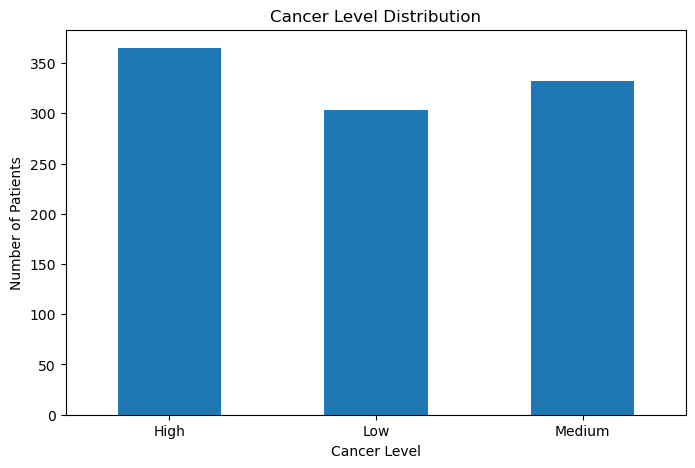

In [7]:
# ==========================================
# LOGISTIC REGRESSION - CANCER DATASET
# ==========================================

# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.preprocessing import LabelEncoder


# ==========================================
# 2. Load dataset
# ==========================================

df = pd.read_excel("cancer.csv")

print("First 5 rows:")
print(df.head())


# ==========================================
# 3. Dataset information
# ==========================================

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)


# ==========================================
# 4. Check target values
# ==========================================

print("\nCancer Level Counts:")
print(df["Level"].value_counts())


# ==========================================
# 5. Remove Patient ID
# ==========================================

df = df.drop("Patient Id", axis=1)


# ==========================================
# 6. Convert Level into numbers
# ==========================================

label_encoder = LabelEncoder()

df["Level"] = label_encoder.fit_transform(df["Level"])

print("\nEncoded Classes:")
print(label_encoder.classes_)


# ==========================================
# 7. Separate input and output
# ==========================================

X = df.drop("Level", axis=1)

y = df["Level"]


# ==========================================
# 8. Split dataset
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


# ==========================================
# 9. Create Logistic Regression model
# ==========================================

model = LogisticRegression(max_iter=1000)


# ==========================================
# 10. Train model
# ==========================================

model.fit(X_train, y_train)


# ==========================================
# 11. Prediction
# ==========================================

y_pred = model.predict(X_test)


# ==========================================
# 12. Accuracy
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

print("Accuracy Percentage:",
      accuracy * 100, "%")


# ==========================================
# 13. Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# ==========================================
# 14. Classification Report
# ==========================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)


# ==========================================
# 15. Graph
# ==========================================

plt.figure(figsize=(8, 5))

df["Level"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Cancer Level")
plt.ylabel("Number of Patients")

plt.title("Cancer Level Distribution")

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=0
)

plt.show()

First 5 rows:
  Patient Id  Age  Gender  Air Pollution  Alcohol use  Dust Allergy  \
0         P1   33       1              2            4             5   
1        P10   17       1              3            1             5   
2       P100   35       1              4            5             6   
3      P1000   37       1              7            7             7   
4       P101   46       1              6            8             7   

   OccuPational Hazards  Genetic Risk  chronic Lung Disease  Balanced Diet  \
0                     4             3                     2              2   
1                     3             4                     2              2   
2                     5             5                     4              6   
3                     7             6                     7              7   
4                     7             7                     6              7   

   ...  Fatigue  Weight Loss  Shortness of Breath  Wheezing  \
0  ...        3            

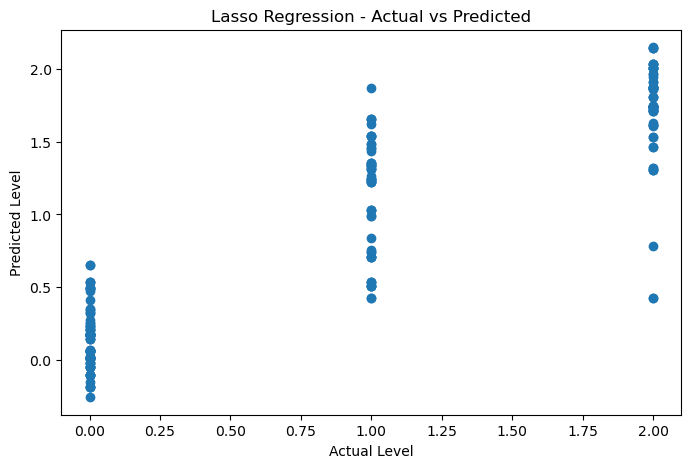

In [8]:
# ==========================================
# LASSO REGRESSION - CANCER DATASET
# ==========================================

# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

from sklearn.preprocessing import LabelEncoder


# ==========================================
# 2. Load dataset
# ==========================================

df = pd.read_excel("cancer.csv")

print("First 5 rows:")
print(df.head())


# ==========================================
# 3. Dataset information
# ==========================================

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)


# ==========================================
# 4. Check target values
# ==========================================

print("\nCancer Level Counts:")
print(df["Level"].value_counts())


# ==========================================
# 5. Remove Patient ID
# ==========================================

df = df.drop("Patient Id", axis=1)


# ==========================================
# 6. Convert Level into numbers
# ==========================================

label_encoder = LabelEncoder()

df["Level"] = label_encoder.fit_transform(df["Level"])

print("\nEncoded Classes:")
print(label_encoder.classes_)


# ==========================================
# 7. Separate input and output
# ==========================================

X = df.drop("Level", axis=1)

y = df["Level"]


# ==========================================
# 8. Split dataset
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


# ==========================================
# 9. Create Lasso Regression model
# ==========================================

model = Lasso(alpha=0.01)


# ==========================================
# 10. Train model
# ==========================================

model.fit(X_train, y_train)


# ==========================================
# 11. Prediction
# ==========================================

y_pred = model.predict(X_test)


# ==========================================
# 12. Mean Squared Error
# ==========================================

mse = mean_squared_error(y_test, y_pred)

print("\nMean Squared Error:", mse)


# ==========================================
# 13. Mean Absolute Error
# ==========================================

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)


# ==========================================
# 14. R2 Score
# ==========================================

r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)


# ==========================================
# 15. Display coefficients
# ==========================================

print("\nFeature Coefficients:")

for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)


# ==========================================
# 16. Graph
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Level")
plt.ylabel("Predicted Level")

plt.title("Lasso Regression - Actual vs Predicted")

plt.show()

First 5 rows:
  Patient Id  Age  Gender  Air Pollution  Alcohol use  Dust Allergy  \
0         P1   33       1              2            4             5   
1        P10   17       1              3            1             5   
2       P100   35       1              4            5             6   
3      P1000   37       1              7            7             7   
4       P101   46       1              6            8             7   

   OccuPational Hazards  Genetic Risk  chronic Lung Disease  Balanced Diet  \
0                     4             3                     2              2   
1                     3             4                     2              2   
2                     5             5                     4              6   
3                     7             6                     7              7   
4                     7             7                     6              7   

   ...  Fatigue  Weight Loss  Shortness of Breath  Wheezing  \
0  ...        3            

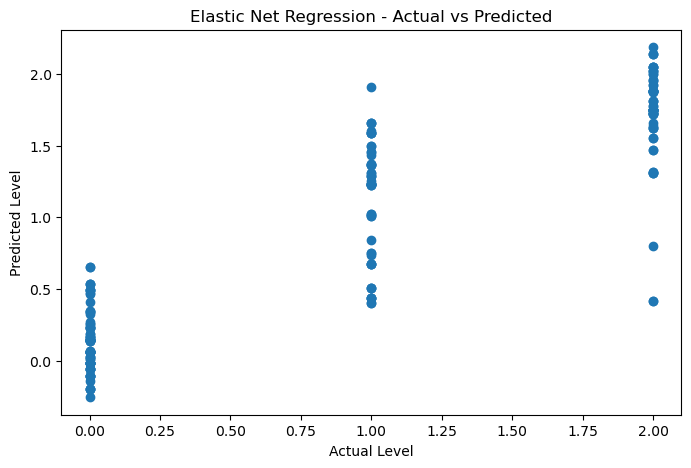

In [9]:
# ==========================================
# ELASTIC NET REGRESSION - CANCER DATASET
# ==========================================

# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNet

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

from sklearn.preprocessing import LabelEncoder


# ==========================================
# 2. Load dataset
# ==========================================

df = pd.read_excel("cancer.csv")

print("First 5 rows:")
print(df.head())


# ==========================================
# 3. Dataset information
# ==========================================

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)


# ==========================================
# 4. Check target values
# ==========================================

print("\nCancer Level Counts:")
print(df["Level"].value_counts())


# ==========================================
# 5. Remove Patient ID
# ==========================================

df = df.drop("Patient Id", axis=1)


# ==========================================
# 6. Convert Level into numbers
# ==========================================

label_encoder = LabelEncoder()

df["Level"] = label_encoder.fit_transform(df["Level"])

print("\nEncoded Classes:")
print(label_encoder.classes_)


# ==========================================
# 7. Separate input and output
# ==========================================

X = df.drop("Level", axis=1)

y = df["Level"]


# ==========================================
# 8. Split dataset
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


# ==========================================
# 9. Create Elastic Net model
# ==========================================

model = ElasticNet(
    alpha=0.01,
    l1_ratio=0.5
)


# ==========================================
# 10. Train model
# ==========================================

model.fit(X_train, y_train)


# ==========================================
# 11. Prediction
# ==========================================

y_pred = model.predict(X_test)


# ==========================================
# 12. Mean Squared Error
# ==========================================

mse = mean_squared_error(y_test, y_pred)

print("\nMean Squared Error:", mse)


# ==========================================
# 13. Mean Absolute Error
# ==========================================

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)


# ==========================================
# 14. R2 Score
# ==========================================

r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)


# ==========================================
# 15. Display coefficients
# ==========================================

print("\nFeature Coefficients:")

for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)


# ==========================================
# 16. Graph
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Level")
plt.ylabel("Predicted Level")

plt.title("Elastic Net Regression - Actual vs Predicted")

plt.show()